In [1]:
import os
import time
import math
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image, ImageDraw
import glob

folder_path = "images/traffic_lights"
IMAGE_PATHS = glob.glob(os.path.join(folder_path, "*.png"))

OUTPUT_DIR = "outputs_part1_corrected"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
def read_image_rgb(path):
    """
    Read image using OpenCV.
    cv2.imread and cv2.cvtColor are allowed by the assignment.
    """
    bgr = cv2.imread(path)
    if bgr is None:
        raise FileNotFoundError(f"Image not found: {path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return rgb


def resize_max_pil(rgb, max_dim=700):
    """
    Resize image for faster Hough voting.
    The final overlay is drawn back on the original image.
    """
    h, w = rgb.shape[:2]
    scale = min(1.0, max_dim / max(h, w))

    if scale == 1.0:
        return rgb.copy(), 1.0

    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    img = Image.fromarray(rgb.astype(np.uint8))
    img = img.resize((new_w, new_h), Image.Resampling.BILINEAR)
    return np.array(img), scale


def rgb_to_gray(rgb):
    """
    Convert RGB to grayscale from scratch using the luminance formula.
    """
    rgb = rgb.astype(np.float32)
    gray = 0.299 * rgb[:, :, 0] + 0.587 * rgb[:, :, 1] + 0.114 * rgb[:, :, 2]
    return gray.astype(np.float32)


def show_rgb(img, title="", figsize=(10, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_gray(img, title="", figsize=(10, 6), cmap="gray"):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [3]:
def convolve2d_from_scratch(image, kernel):
    """
    2D convolution from scratch.
    No scipy.signal.convolve2d, cv2.filter2D, cv2.Sobel, or cv2.Canny is used.
    The outer loops are only over the small kernel size, not image pixels.
    """
    image = image.astype(np.float32)
    kernel = np.flipud(np.fliplr(kernel)).astype(np.float32)

    kh, kw = kernel.shape
    ph = kh // 2
    pw = kw // 2

    padded = np.pad(image, ((ph, ph), (pw, pw)), mode="reflect")
    output = np.zeros_like(image, dtype=np.float32)

    for i in range(kh):
        for j in range(kw):
            output += kernel[i, j] * padded[i:i + image.shape[0], j:j + image.shape[1]]

    return output


def gaussian_kernel(size=5, sigma=1.1):
    """
    Create Gaussian kernel from scratch.
    """
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel.astype(np.float32)


def gaussian_blur_from_scratch(gray, size=5, sigma=1.1):
    kernel = gaussian_kernel(size=size, sigma=sigma)
    return convolve2d_from_scratch(gray, kernel)


def sobel_edges_from_scratch(gray):
    """
    Sobel edge detection from scratch.
    Returns Gx, Gy, magnitude, gradient direction, and normalized magnitude.
    """
    blurred = gaussian_blur_from_scratch(gray, size=5, sigma=1.1)

    sobel_x = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=np.float32)

    sobel_y = np.array([
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1]
    ], dtype=np.float32)

    gx = convolve2d_from_scratch(blurred, sobel_x)
    gy = convolve2d_from_scratch(blurred, sobel_y)

    magnitude = np.sqrt(gx**2 + gy**2)
    theta = np.arctan2(gy, gx)
    mag_norm = magnitude / (magnitude.max() + 1e-8)

    return gx, gy, magnitude, theta, mag_norm

In [4]:
def color_activity_mask(rgb):
    """
    Approximate mask for active lamps.
    Used only to help estimate ROI; it does not replace Hough detection.
    """
    rgb = rgb.astype(np.float32)
    R = rgb[:, :, 0]
    G = rgb[:, :, 1]
    B = rgb[:, :, 2]

    maxc = np.maximum.reduce([R, G, B])
    minc = np.minimum.reduce([R, G, B])
    sat = maxc - minc

    red = (R > 110) & (R > 1.35 * G) & (R > 1.35 * B) & (sat > 50)
    green = (G > 120) & (G > 1.05 * R) & (G > 0.85 * B) & (sat > 50)
    yellow = (R > 130) & (G > 110) & (B < 120) & (np.abs(R - G) < 80) & (sat > 50)

    return red | green | yellow


def find_traffic_light_roi(rgb):
    """
    Estimate a region of interest to reduce false positives.
    If an active lamp is visible, expand around it. Otherwise, use dark housing regions.
    """
    h, w = rgb.shape[:2]
    gray = rgb_to_gray(rgb)

    active = color_activity_mask(rgb)
    ys, xs = np.where(active)

    if len(xs) > 30:
        x1, x2 = xs.min(), xs.max()
        y1, y2 = ys.min(), ys.max()

        mx = int(0.18 * w)
        my = int(0.30 * h)

        x1 = max(0, x1 - mx)
        x2 = min(w, x2 + mx)
        y1 = max(0, y1 - my)
        y2 = min(h, y2 + my)

        return int(x1), int(y1), int(x2), int(y2)

    dark = gray < np.percentile(gray, 35)
    ys, xs = np.where(dark)

    if len(xs) == 0:
        return 0, 0, w, h

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    mx = int(0.08 * w)
    my = int(0.08 * h)

    return (
        int(max(0, x1 - mx)),
        int(max(0, y1 - my)),
        int(min(w, x2 + mx)),
        int(min(h, y2 + my))
    )


def circle_inner_mask(shape, cx, cy, r, scale=0.62):
    """
    Mask inside the circle for color analysis.
    scale < 1 avoids dark borders of lamp housing.
    """
    h, w = shape[:2]
    yy, xx = np.ogrid[:h, :w]
    rr = r * scale
    mask = (xx - cx)**2 + (yy - cy)**2 <= rr**2
    return mask


def classify_light_color(rgb, cx, cy, r):
    """
    Classify lamp state as RED, YELLOW, GREEN, or UNLIT.
    Uses ratio of bright and saturated color pixels inside each detected circle.
    """
    mask = circle_inner_mask(rgb.shape, cx, cy, r, scale=0.62)
    pixels = rgb[mask].astype(np.float32)

    if len(pixels) < 20:
        return "UNLIT", {
            "brightness": 0.0,
            "RED": 0.0,
            "YELLOW": 0.0,
            "GREEN": 0.0,
            "active_ratio": 0.0,
            "saturation": 0.0
        }

    R = pixels[:, 0]
    G = pixels[:, 1]
    B = pixels[:, 2]

    brightness = 0.299 * R + 0.587 * G + 0.114 * B
    maxc = np.maximum.reduce([R, G, B])
    minc = np.minimum.reduce([R, G, B])
    sat = maxc - minc

    red_pixels = (
        (R > 110) &
        (R > 1.35 * G) &
        (R > 1.35 * B) &
        (sat > 55) &
        (brightness > 65)
    )

    green_pixels = (
        (G > 120) &
        (G > 1.05 * R) &
        (G > 0.85 * B) &
        (sat > 55) &
        (brightness > 90)
    )

    yellow_pixels = (
        (R > 130) &
        (G > 110) &
        (B < 120) &
        (np.abs(R - G) < 80) &
        (sat > 55) &
        (brightness > 100)
    )

    ratios = {
        "RED": float(np.mean(red_pixels)),
        "YELLOW": float(np.mean(yellow_pixels)),
        "GREEN": float(np.mean(green_pixels))
    }

    label = max(ratios, key=ratios.get)
    active_ratio = ratios[label]

    if active_ratio < 0.10:
        label = "UNLIT"

    info = {
        "brightness": float(np.mean(brightness)),
        "RED": ratios["RED"],
        "YELLOW": ratios["YELLOW"],
        "GREEN": ratios["GREEN"],
        "active_ratio": float(active_ratio),
        "saturation": float(np.mean(sat))
    }

    return label, info

In [5]:
def hough_circles_gradient(edges, theta, radius_range, roi=None, max_edges=12000):
    """
    From-scratch 3D Hough Circle Transform.

    Accumulator space:
        accumulator[r, y_center, x_center]

    Gradient optimization:
        a = x ± r cos(theta)
        b = y ± r sin(theta)

    This avoids voting over all circle angles for each edge pixel.
    """
    h, w = edges.shape
    radii = np.array(list(radius_range), dtype=np.int32)
    accumulator = np.zeros((len(radii), h, w), dtype=np.uint16)

    if roi is None:
        x1, y1, x2, y2 = 0, 0, w, h
    else:
        x1, y1, x2, y2 = roi

    roi_mask = np.zeros_like(edges, dtype=bool)
    roi_mask[y1:y2, x1:x2] = True

    valid_edges = edges & roi_mask
    ys, xs = np.where(valid_edges)

    if len(xs) == 0:
        return accumulator, radii

    if len(xs) > max_edges:
        idx = np.linspace(0, len(xs) - 1, max_edges).astype(np.int32)
        xs = xs[idx]
        ys = ys[idx]

    edge_theta = theta[ys, xs]
    cos_t = np.cos(edge_theta)
    sin_t = np.sin(edge_theta)

    for ridx, r in enumerate(radii):
        for sign in [1, -1]:
            a = np.round(xs + sign * r * cos_t).astype(np.int32)
            b = np.round(ys + sign * r * sin_t).astype(np.int32)

            valid = (a >= 0) & (a < w) & (b >= 0) & (b < h)
            np.add.at(accumulator[ridx], (b[valid], a[valid]), 1)

    return accumulator, radii


def extract_hough_peaks(accumulator, radii, roi=None, top_k=120, min_distance=15):
    """
    Extract strong peaks from the 3D accumulator using simple non-maximum suppression.
    """
    flat = accumulator.ravel()
    candidate_count = min(top_k * 8, flat.size)
    idxs = np.argpartition(flat, -candidate_count)[-candidate_count:]
    idxs = idxs[np.argsort(flat[idxs])[::-1]]

    circles = []

    for idx in idxs:
        ridx, y, x = np.unravel_index(idx, accumulator.shape)
        votes = int(accumulator[ridx, y, x])
        r = int(radii[ridx])

        if votes <= 0:
            break

        if roi is not None:
            x1, y1, x2, y2 = roi
            if not (x1 <= x < x2 and y1 <= y < y2):
                continue

        duplicate = False
        for cx, cy, cr, cv in circles:
            dist = np.sqrt((x - cx)**2 + (y - cy)**2)
            if dist < 0.7 * max(r, cr):
                duplicate = True
                break

        if not duplicate:
            circles.append((int(x), int(y), int(r), int(votes)))

        if len(circles) >= top_k:
            break

    return circles


def accumulator_heatmap(accumulator):
    """
    Convert 3D accumulator to a 2D heatmap for visualization.
    Max is taken over radius dimension.
    """
    heat = accumulator.max(axis=0).astype(np.float32)
    if heat.max() > 0:
        heat = heat / heat.max()
    return heat

In [6]:
def select_three_traffic_lamps(rgb, hough_circles):
    """
    Select the three main traffic-light lamps.

    Logic:
    - classify each candidate
    - find the strongest active lamp
    - infer top/middle/bottom lamp slots based on RED/YELLOW/GREEN
    - select vertically aligned, similar-radius circles
    """
    h, w = rgb.shape[:2]

    items = []
    for cx, cy, r, votes in hough_circles:
        label, info = classify_light_color(rgb, cx, cy, r)
        score = votes + 120 * info["active_ratio"]
        items.append({
            "cx": int(cx),
            "cy": int(cy),
            "r": int(r),
            "votes": int(votes),
            "label": label,
            "info": info,
            "score": float(score)
        })

    if len(items) == 0:
        return []

    active_items = [it for it in items if it["label"] != "UNLIT"]

    if len(active_items) == 0:
        selected = sorted(items, key=lambda d: d["votes"], reverse=True)[:3]
        return sorted(selected, key=lambda d: d["cy"])

    best_active = max(active_items, key=lambda d: d["score"])

    cx0 = best_active["cx"]
    cy0 = best_active["cy"]
    r0 = best_active["r"]
    label0 = best_active["label"]

    slot_index = {
        "RED": 0,
        "YELLOW": 1,
        "GREEN": 2
    }.get(label0, 0)

    min_spacing = max(int(2.0 * r0), 45)
    max_spacing = min(int(4.0 * r0), int(h / 2))

    best_trio = None
    best_score = -1e18

    for spacing in range(min_spacing, max_spacing + 1, 2):
        y_top = cy0 - slot_index * spacing

        if y_top - r0 < 0:
            continue
        if y_top + 2 * spacing + r0 >= h:
            continue

        trio = []
        total_score = 0.0

        for slot in range(3):
            y_pred = y_top + slot * spacing
            best_match = None
            best_local_score = -1e18

            for it in items:
                dx = abs(it["cx"] - cx0)
                dy = abs(it["cy"] - y_pred)
                dr = abs(it["r"] - r0)

                if dx < 1.5 * r0 and dy < 0.50 * spacing and dr < 0.7 * r0:
                    local_score = (
                        it["votes"]
                        - 0.45 * dx
                        - 0.25 * dy
                        - 0.20 * dr
                    )

                    if slot == slot_index:
                        local_score += 120 * it["info"]["active_ratio"]
                        if it["label"] == label0:
                            local_score += 80
                    else:
                        if it["label"] == "UNLIT":
                            local_score += 25
                        else:
                            local_score -= 120 * it["info"]["active_ratio"] + 80

                    if local_score > best_local_score:
                        best_local_score = local_score
                        best_match = it

            if best_match is not None:
                chosen = best_match.copy()
                total_score += best_local_score
            else:
                chosen = {
                    "cx": int(cx0),
                    "cy": int(round(y_pred)),
                    "r": int(r0),
                    "votes": 0,
                    "label": "UNLIT",
                    "info": {
                        "brightness": 0.0,
                        "RED": 0.0,
                        "YELLOW": 0.0,
                        "GREEN": 0.0,
                        "active_ratio": 0.0,
                        "saturation": 0.0
                    },
                    "score": 0.0
                }
                total_score -= 15

            label, info = classify_light_color(rgb, chosen["cx"], chosen["cy"], chosen["r"])
            chosen["label"] = label
            chosen["info"] = info

            if slot != slot_index and chosen["label"] != "UNLIT":
                if chosen["info"]["active_ratio"] < 0.35:
                    chosen["label"] = "UNLIT"

            trio.append(chosen)

        x_std = np.std([t["cx"] for t in trio])
        total_score -= 0.5 * x_std

        if total_score > best_score:
            best_score = total_score
            best_trio = trio

    if best_trio is None:
        selected = sorted(items, key=lambda d: d["score"], reverse=True)[:3]
        return sorted(selected, key=lambda d: d["cy"])

    return sorted(best_trio, key=lambda d: d["cy"])

In [7]:
def scale_circles_to_original(circles, scale):
    """
    Map circle coordinates from resized image to original image.
    """
    if scale == 1.0:
        return circles

    scaled = []
    for c in circles:
        item = c.copy()
        item["cx"] = int(round(item["cx"] / scale))
        item["cy"] = int(round(item["cy"] / scale))
        item["r"] = int(round(item["r"] / scale))
        scaled.append(item)
    return scaled


def draw_final_overlay(rgb_original, circles):
    """
    Draw circle and state text on the original image.
    """
    img = Image.fromarray(rgb_original.astype(np.uint8))
    draw = ImageDraw.Draw(img)

    for c in circles:
        cx = c["cx"]
        cy = c["cy"]
        r = c["r"]
        label = c["label"]

        if label == "RED":
            color = (255, 0, 0)
        elif label == "YELLOW":
            color = (255, 220, 0)
        elif label == "GREEN":
            color = (0, 255, 0)
        else:
            color = (180, 180, 180)

        width = max(3, r // 12)
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], outline=color, width=width)
        draw.text((cx + r + 8, cy - r), label, fill=color)

    return np.array(img)

In [8]:
def process_one_image(path, max_dim=700):
    result = {}
    times = {}

    t0 = time.time()
    rgb_original = read_image_rgb(path)
    
    rgb_small, scale = resize_max_pil(rgb_original, max_dim=max_dim)
    gray = rgb_to_gray(rgb_small)
    times["read_resize_grayscale"] = time.time() - t0

    t0 = time.time()
    roi = find_traffic_light_roi(rgb_small)
    times["roi_detection"] = time.time() - t0

    t0 = time.time()
    gx, gy, magnitude, theta, mag_norm = sobel_edges_from_scratch(gray)
    times["edge_detection"] = time.time() - t0

    x1, y1, x2, y2 = roi
    roi_mag = mag_norm[y1:y2, x1:x2]

    if roi_mag.size > 0:
        edge_threshold = np.percentile(roi_mag, 86)
    else:
        edge_threshold = np.percentile(mag_norm, 88)

    edges = mag_norm >= edge_threshold

    h, w = gray.shape
    min_r = max(10, int(min(h, w) * 0.03))
    max_r = max(min_r + 8, int(min(h, w) * 0.105))
    radius_range = range(min_r, max_r + 1, 2)

    t0 = time.time()
    accumulator, radii = hough_circles_gradient(
        edges=edges,
        theta=theta,
        radius_range=radius_range,
        roi=roi,
        max_edges=12000
    )
    times["hough_voting"] = time.time() - t0

    t0 = time.time()
    raw_circles = extract_hough_peaks(
        accumulator=accumulator,
        radii=radii,
        roi=roi,
        top_k=120,
        min_distance=min_r
    )

    selected_small = select_three_traffic_lamps(rgb_small, raw_circles)
    selected_original = scale_circles_to_original(selected_small, scale)
    overlay_original = draw_final_overlay(rgb_original, selected_original)
    heatmap = accumulator_heatmap(accumulator)
    times["postprocess_classification_visualization"] = time.time() - t0

    result["path"] = path
    result["rgb_original"] = rgb_original
    result["rgb_small"] = rgb_small
    result["scale"] = scale
    result["gray"] = gray
    result["edges"] = edges
    result["magnitude"] = magnitude
    result["theta"] = theta
    result["roi"] = roi
    result["accumulator"] = accumulator
    result["heatmap"] = heatmap
    result["raw_circles"] = raw_circles
    result["selected_small"] = selected_small
    result["selected_original"] = selected_original
    result["overlay_original"] = overlay_original
    result["times"] = times

    return result

In [ ]:
all_results = []

for path in IMAGE_PATHS:
    print("=" * 90)
    print(f"Processing: {path}")

    result = process_one_image(path, max_dim=700)
    all_results.append(result)

    print("\nROI on resized image:")
    print(result["roi"])

    print("\nDetected lamps on ORIGINAL image:")
    for c in result["selected_original"]:
        print(
            f"center=({c['cx']}, {c['cy']}), "
            f"r={c['r']}, "
            f"votes={c['votes']}, "
            f"label={c['label']}, "
            f"active_ratio={c['info']['active_ratio']:.3f}, "
            f"brightness={c['info']['brightness']:.2f}"
        )

    print("\nExecution times:")
    for k, v in result["times"].items():
        print(f"{k}: {v:.4f} sec")

Processing: images/traffic_lights\green_light_1.png

ROI on resized image:
(0, 0, 700, 466)

Detected lamps on ORIGINAL image:
center=(910, 156), r=77, votes=12, label=UNLIT, active_ratio=0.000, brightness=11.87
center=(914, 357), r=81, votes=7, label=UNLIT, active_ratio=0.000, brightness=13.40
center=(914, 555), r=67, votes=14, label=GREEN, active_ratio=1.000, brightness=205.10

Execution times:
read_resize_grayscale: 0.1879 sec
roi_detection: 0.0445 sec
edge_detection: 0.1192 sec
hough_voting: 0.1249 sec
postprocess_classification_visualization: 1.3486 sec
Processing: images/traffic_lights\red_light_1.png



ROI on resized image:
(0, 0, 700, 466)

Detected lamps on ORIGINAL image:
center=(910, 156), r=77, votes=12, label=UNLIT, active_ratio=0.000, brightness=11.87
center=(914, 357), r=81, votes=7, label=UNLIT, active_ratio=0.000, brightness=13.40
center=(914, 555), r=67, votes=14, label=GREEN, active_ratio=1.000, brightness=205.10

Execution times:
read_resize_grayscale: 0.2595 sec
roi_detection: 0.1156 sec
edge_detection: 0.0226 sec
hough_voting: 0.0736 sec
postprocess_classification_visualization: 0.5565 sec
Processing: red_light_1.png



ROI on resized image:
(207, 0, 700, 394)

Detected lamps on ORIGINAL image:
center=(453, 83), r=50, votes=12, label=RED, active_ratio=1.000, brightness=127.55
center=(452, 190), r=47, votes=16, label=UNLIT, active_ratio=0.000, brightness=40.50
center=(450, 309), r=47, votes=17, label=UNLIT, active_ratio=0.000, brightness=39.66

Execution times:
read_resize_grayscale: 0.0115 sec
roi_detection: 0.0137 sec
edge_detection: 0.0193 sec
hough_voting: 0.0588 sec
postprocess_classification_visualization: 0.3607 sec
Processing: red_light_2.png



ROI on resized image:
(0, 0, 646, 467)

Detected lamps on ORIGINAL image:
center=(813, 266), r=51, votes=11, label=RED, active_ratio=1.000, brightness=98.55
center=(821, 432), r=31, votes=7, label=UNLIT, active_ratio=0.000, brightness=61.12
center=(802, 590), r=45, votes=8, label=UNLIT, active_ratio=0.000, brightness=57.73

Execution times:
read_resize_grayscale: 0.0303 sec
roi_detection: 0.0302 sec
edge_detection: 0.0211 sec
hough_voting: 0.0704 sec
postprocess_classification_visualization: 0.4276 sec


## 9. Visualize intermediate and final results

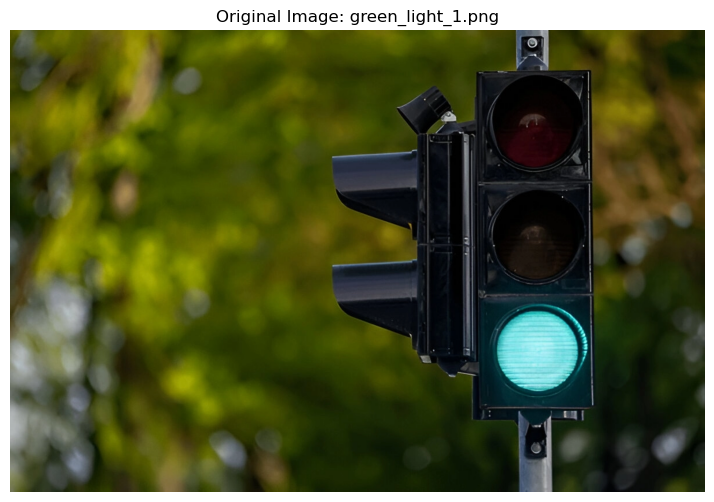

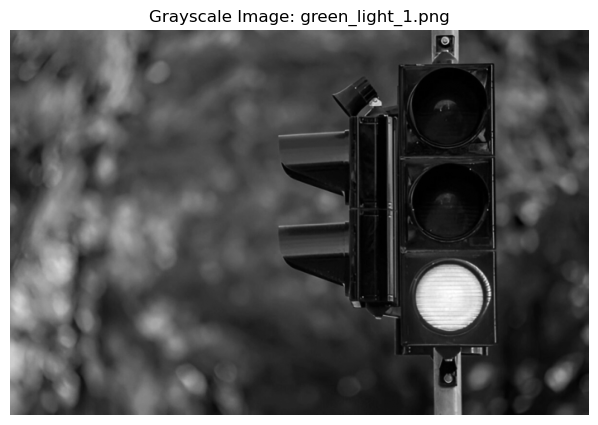

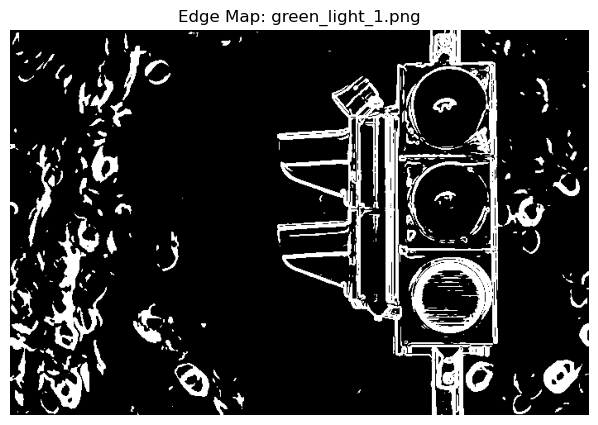

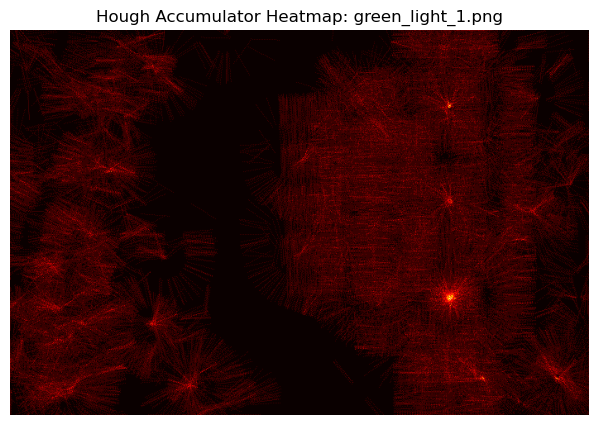

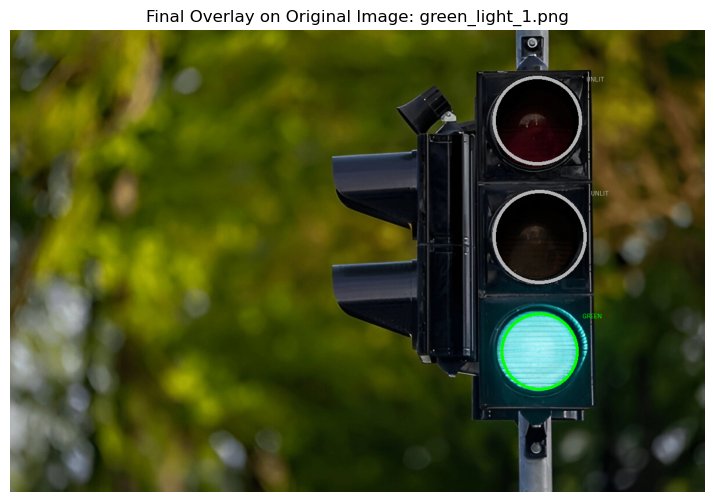

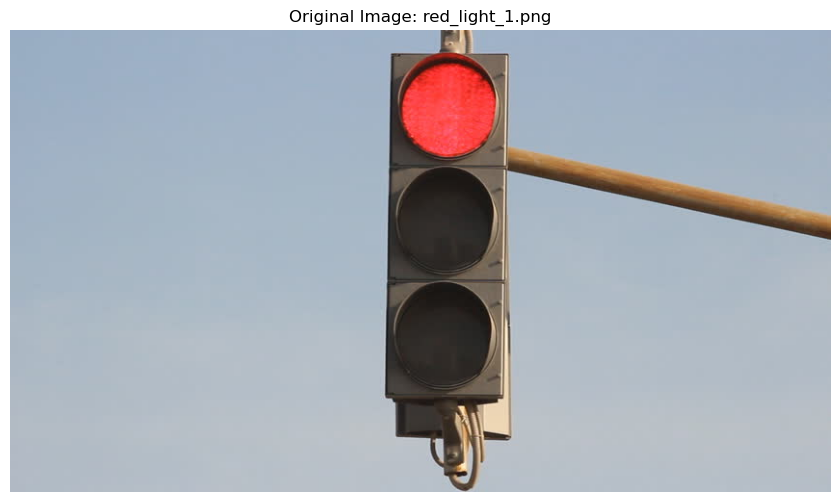

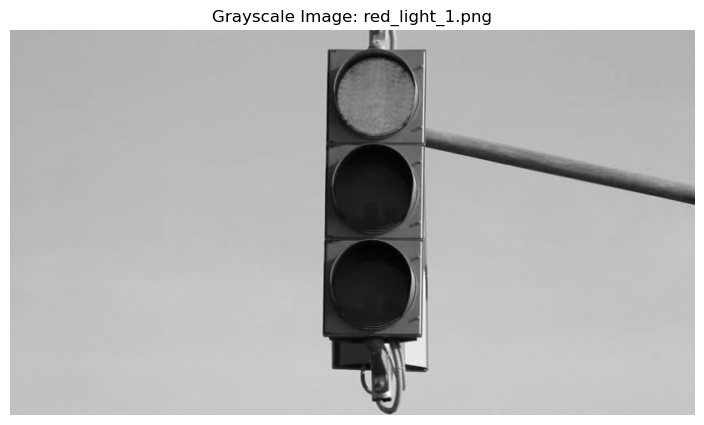

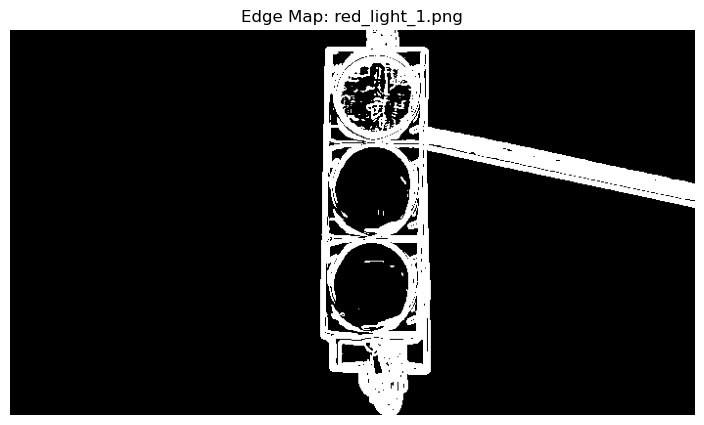

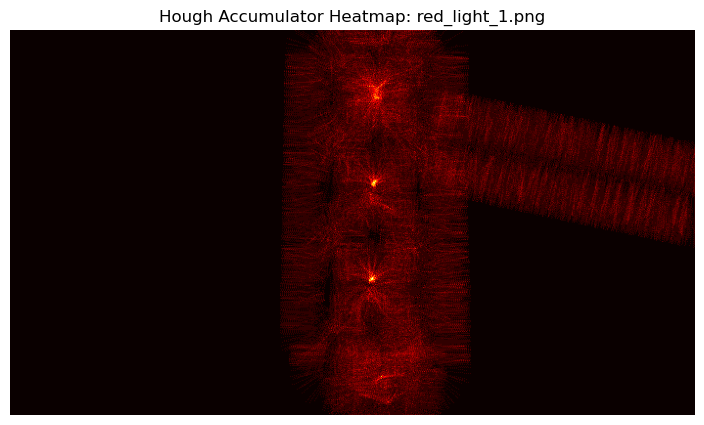

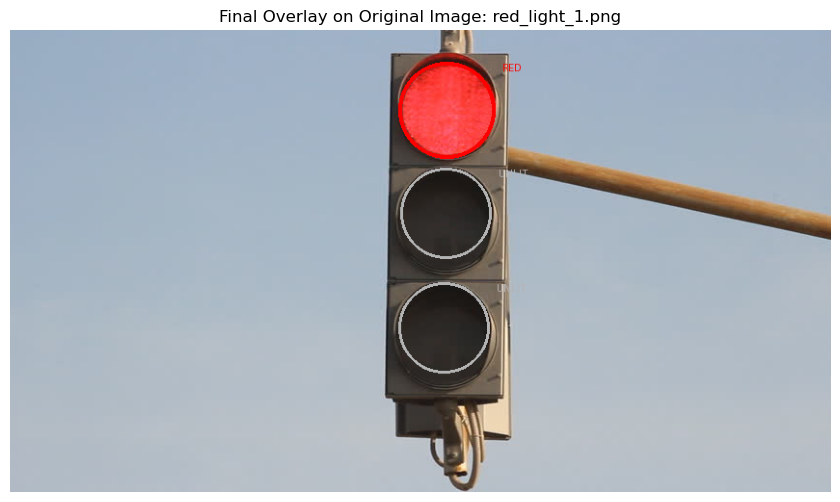

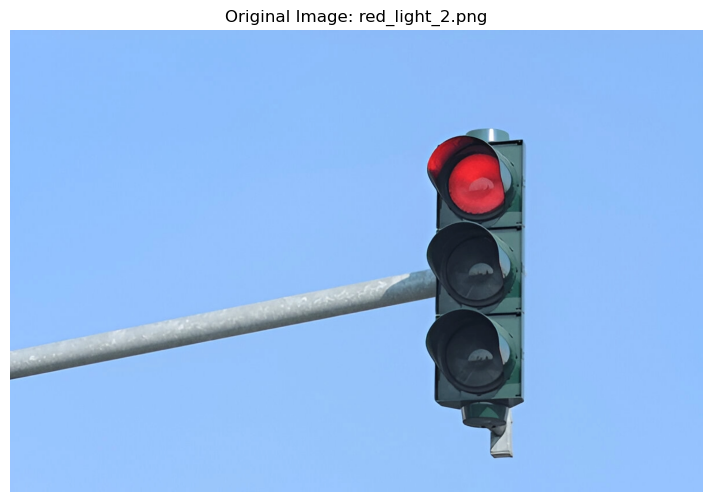

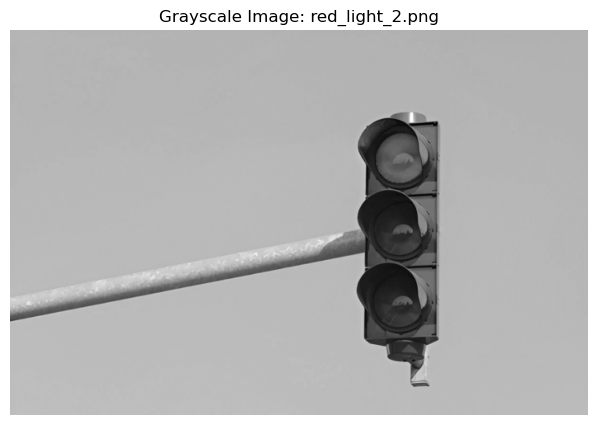

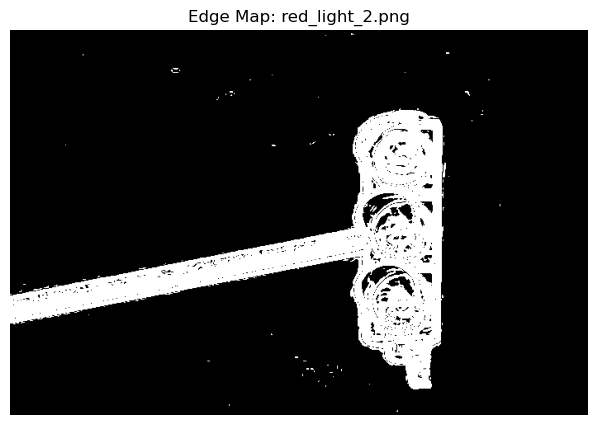

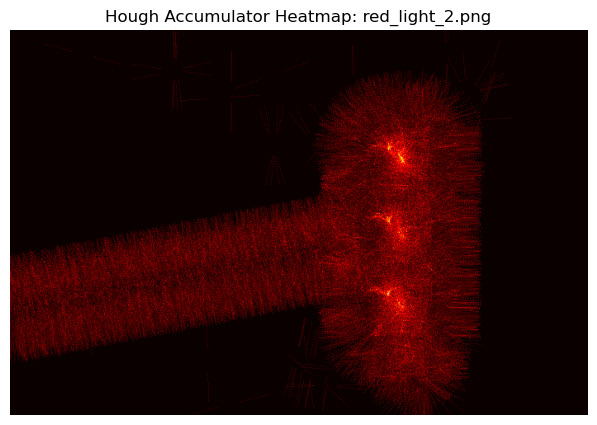

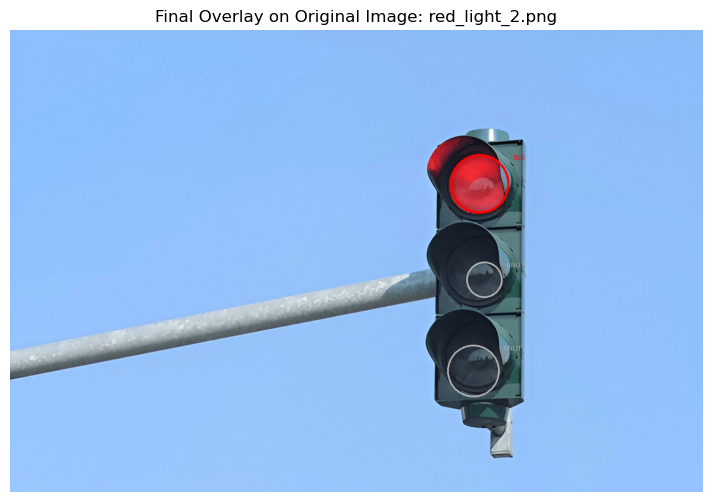

In [13]:
for result in all_results:
    base = os.path.basename(result["path"])

    show_rgb(result["rgb_original"], title=f"Original Image: {base}", figsize=(12, 6))
    show_gray(result["gray"], title=f"Grayscale Image: {base}", figsize=(10, 5))
    show_gray(result["edges"], title=f"Edge Map: {base}", figsize=(10, 5))
    show_gray(result["heatmap"], title=f"Hough Accumulator Heatmap: {base}", figsize=(10, 5), cmap="hot")
    show_rgb(result["overlay_original"], title=f"Final Overlay on Original Image: {base}", figsize=(12, 6))

## 10. Save report outputs

In [14]:
for result in all_results:
    base = os.path.splitext(os.path.basename(result["path"]))[0]

    overlay_path = os.path.join(OUTPUT_DIR, f"{base}_final_overlay.png")
    gray_path = os.path.join(OUTPUT_DIR, f"{base}_grayscale.png")
    edge_path = os.path.join(OUTPUT_DIR, f"{base}_edge_map.png")
    heatmap_path = os.path.join(OUTPUT_DIR, f"{base}_hough_heatmap.png")

    Image.fromarray(result["overlay_original"].astype(np.uint8)).save(overlay_path)

    gray_uint8 = result["gray"]
    gray_uint8 = 255 * (gray_uint8 - gray_uint8.min()) / (gray_uint8.max() - gray_uint8.min() + 1e-8)
    Image.fromarray(gray_uint8.astype(np.uint8)).save(gray_path)

    edge_uint8 = result["edges"].astype(np.uint8) * 255
    Image.fromarray(edge_uint8).save(edge_path)

    plt.imsave(heatmap_path, result["heatmap"], cmap="hot")

    print(f"Saved outputs for {base}:")
    print(f"  {overlay_path}")
    print(f"  {gray_path}")
    print(f"  {edge_path}")
    print(f"  {heatmap_path}")

Saved outputs for green_light_1:
  outputs_part1_corrected\green_light_1_final_overlay.png
  outputs_part1_corrected\green_light_1_grayscale.png
  outputs_part1_corrected\green_light_1_edge_map.png
  outputs_part1_corrected\green_light_1_hough_heatmap.png
Saved outputs for red_light_1:
  outputs_part1_corrected\red_light_1_final_overlay.png
  outputs_part1_corrected\red_light_1_grayscale.png
  outputs_part1_corrected\red_light_1_edge_map.png
  outputs_part1_corrected\red_light_1_hough_heatmap.png
Saved outputs for red_light_2:
  outputs_part1_corrected\red_light_2_final_overlay.png
  outputs_part1_corrected\red_light_2_grayscale.png
  outputs_part1_corrected\red_light_2_edge_map.png
  outputs_part1_corrected\red_light_2_hough_heatmap.png


Saved outputs for red_light_2:
  outputs_part1_corrected/red_light_2_final_overlay.png
  outputs_part1_corrected/red_light_2_grayscale.png
  outputs_part1_corrected/red_light_2_edge_map.png
  outputs_part1_corrected/red_light_2_hough_heatmap.png


## 11. Execution-time table

In [12]:
rows = []

for result in all_results:
    row = {"image": os.path.basename(result["path"])}
    for k, v in result["times"].items():
        row[k] = v
    row["total_time"] = sum(result["times"].values())
    rows.append(row)

time_table = pd.DataFrame(rows)
time_table

,image,read_resize_grayscale,roi_detection,edge_detection,hough_voting,postprocess_classification_visualization,total_time
0,green_light_1.png,0.259502,0.115634,0.022587,0.073560,0.556465,1.027749
1,red_light_1.png,0.011516,0.013658,0.019272,0.058753,0.360710,0.463908
2,red_light_2.png,0.030284,0.030160,0.021080,0.070366,0.427558,0.579449


In [13]:
average_time_table = time_table.drop(columns=["image"]).mean().to_frame(name="average_time_sec")
average_time_table

,average_time_sec
read_resize_grayscale,0.100434
roi_detection,0.053151
edge_detection,0.020980
hough_voting,0.067560
postprocess_classification_visualization,0.448244
total_time,0.690369
